# CSCN8020 Assignment 1 - Reinforcement Learning Programming

**Name:** Kevinkumar Patel  
**Student ID:** 8998612  
**Course:** CSCN8020 - Reinforcement Learning Programming  

This notebook contains all four problems for Assignment 1. It includes Markdown explanations, code implementation, output tables, figures, logging, and talking points.

**Reference:** Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press.

## Imports and Setup

The code is separated into object-oriented files inside the `src` folder:

- `GridWorldEnvironment` keeps the gridworld environment logic.
- `ValueIterationAgent` runs standard value iteration.
- `InPlaceValueIterationAgent` runs in-place value iteration.
- `MonteCarloOffPolicyAgent` runs off-policy Monte Carlo with importance sampling.
- Utility functions are used for logging and tables.

## Required Development Library and Course Code References

This assignment instruction asked to use Gymnasium and the course GitHub examples. I used them as **reference and guidance**, and then I wrote my own object-oriented version for this assignment.

- **HelloGymMaze / Gymnasium idea:** I used the same environment style where the environment has `reset()`, `step()`, observation space, action space, rewards, and terminal condition. My `GridWorldEnvironment` class extends `gym.Env` when Gymnasium is installed.
- **lec2_MDP:** Used as reference for MDP thinking: states, actions, transition, reward, and policy.
- **lec3_DP:** Used as reference for Dynamic Programming and Value Iteration. My `ValueIterationAgent` and `InPlaceValueIterationAgent` follow the Bellman update idea.
- **lec4_MC:** Used as reference for Monte Carlo learning. My `MonteCarloOffPolicyAgent` uses episodes, returns, behavior policy, target policy, and importance sampling.

Required links checked:

```text
https://github.com/ProfEspinosaAIML/HelloGymMaze.git
https://github.com/CSCN8020/playground/tree/main/lec2_MDP
https://github.com/CSCN8020/playground/tree/main/lec3_DP
https://github.com/CSCN8020/playground/tree/main/lec4_MC
```


In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make sure local src folder can be imported
PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.environments import GridWorldEnvironment
from src.agents import ValueIterationAgent, InPlaceValueIterationAgent, MonteCarloOffPolicyAgent
from src.utils import setup_logger, values_to_dataframe, policy_to_dataframe, plot_value_grid

logger = setup_logger("logs/sample_execution.log")
logger.info("Notebook execution started.")

2026-06-11 14:34:06,035 - INFO - Notebook execution started.


# Problem 1: Pick-and-Place Robot MDP Design

A pick-and-place robot can be designed as a Markov Decision Process because the robot makes decisions step by step. At each step, the robot observes its current condition, chooses a motor/control action, and receives feedback from the environment.

## Agent

The agent is the robot arm controller. It decides how the robot motors and gripper should move.

## States

A state should include the important information needed for the next decision:

- Current joint angles
- Current joint velocities
- End-effector position
- Object position
- Target position
- Gripper status, such as open or closed
- Distance between gripper and object
- Distance between object and target

Example state:

```text
s = [joint angles, joint velocities, gripper status, object position, target position]
```

## Actions

Actions are the robot control commands. Examples are:

- Move joint 1 clockwise or counter-clockwise
- Move joint 2 clockwise or counter-clockwise
- Move end-effector up, down, left, or right
- Open gripper
- Close gripper
- Hold current position

## Rewards

A good reward design should encourage fast and smooth movement:

- Positive reward when the gripper reaches the object
- Bigger positive reward when the object is placed at the target
- Negative reward for collision
- Negative reward for dropping the object
- Small negative reward for every time step to encourage faster work
- Negative reward for jerky or unsafe movement

## Reasoning

This is an MDP because the next state depends mainly on the current state and the action taken by the robot. The robot does not need the full history if the state includes all important information.

## Problem 1 Talking Points

**Talking Point A - Key Reinforcement Learning Feature**  
The main RL feature in this problem is MDP design. I need to clearly define the state, action, and reward because the robot learn from these things. If the reward is not designed properly, the robot may learn wrong movement.

**Talking Point B - Implementation and Testing Challenge**  
One challenge is deciding what should be included in the state. The robot has many details like joint angle, velocity, gripper position, object position and target position. If I miss important information, the agent may not learn smooth and fast movement.

**Talking Point C - Why This Is Reinforcement Learning**  
This is Reinforcement Learning because the robot is an agent and it is learning by taking actions in an environment. It gets reward or penalty after action. This is not normal supervised learning because we are not only giving correct labels, the robot learn from feedback.

**Connection to Sutton and Barto pseudocode**  
The design uses the main RL ideas from Sutton and Barto: agent, environment, state, action, reward, policy, and return. The actual learning would update value or policy from reward feedback.

# Problem 2: 2x2 Gridworld Value Iteration

## Given Information

State space:

```text
S = {s1, s2, s3, s4}
```

Action space:

```text
A = {up, down, left, right}
```

Grid layout assumption:

```text
s1  s2
s3  s4
```

State coordinate mapping:

```text
s1 = (0,0), s2 = (0,1), s3 = (1,0), s4 = (1,1)
```

Rewards:

```text
R(s1)=5, R(s2)=10, R(s3)=1, R(s4)=2
```

Assumption used here:

```text
gamma = 0.9
Initial V0(s) = 0 for all states
```

For this problem I use the reward of the current state, because the assignment writes reward as R(s).

## Manual Step-by-Step Calculation

### Iteration 1

Initial value function:

| State | V0 |
|---|---:|
| s1 | 0 |
| s2 | 0 |
| s3 | 0 |
| s4 | 0 |

Using Bellman optimality update:

```text
V(s) = R(s) + gamma * max V(s')
```

Because all initial values are 0:

```text
V1(s1) = 5 + 0.9(0) = 5
V1(s2) = 10 + 0.9(0) = 10
V1(s3) = 1 + 0.9(0) = 1
V1(s4) = 2 + 0.9(0) = 2
```

Updated value function after iteration 1:

| State | V1 |
|---|---:|
| s1 | 5 |
| s2 | 10 |
| s3 | 1 |
| s4 | 2 |

### Iteration 2

Now use V1 values:

```text
From s1, best next state is s2 with value 10.
V2(s1) = 5 + 0.9(10) = 14

From s2, invalid up/right stays in s2, so best next value is 10.
V2(s2) = 10 + 0.9(10) = 19

From s3, best next state is s1 with value 5.
V2(s3) = 1 + 0.9(5) = 5.5

From s4, best next state is s2 with value 10.
V2(s4) = 2 + 0.9(10) = 11
```

Updated value function after iteration 2:

| State | V2 |
|---|---:|
| s1 | 14 |
| s2 | 19 |
| s3 | 5.5 |
| s4 | 11 |

In [2]:
# Code verification for Problem 2

env_2x2 = GridWorldEnvironment.make_2x2()
gamma = 0.9

V0 = {state: 0.0 for state in env_2x2.states}
V1 = {}
V2 = {}

for state in env_2x2.states:
    next_values = []
    for action in env_2x2.action_names:
        next_state = env_2x2.transition(state, action)
        next_values.append(V0[next_state])
    V1[state] = env_2x2.reward(state) + gamma * max(next_values)

for state in env_2x2.states:
    next_values = []
    for action in env_2x2.action_names:
        next_state = env_2x2.transition(state, action)
        next_values.append(V1[next_state])
    V2[state] = env_2x2.reward(state) + gamma * max(next_values)

print("Iteration 1 Values")
display(values_to_dataframe(V1, 2, 2))

print("Iteration 2 Values")
display(values_to_dataframe(V2, 2, 2))

Iteration 1 Values


,col 0,col 1
row 0,5.0,10.0
row 1,1.0,2.0


Iteration 2 Values


,col 0,col 1
row 0,14.0,19.0
row 1,5.5,11.0


## Problem 2 Talking Points

**Talking Point A - Key Reinforcement Learning Feature**  
The main feature here is value iteration. The value of each state is updated using reward and future value. This connects to Bellman update from Sutton and Barto because every state value depends on best next action.

**Talking Point B - Implementation and Testing Challenge**  
One challenge was handling invalid actions. If the agent moves into wall, it should stay in same state. I had to check this carefully because wrong transition can change all values in the grid.

**Talking Point C - Why This Is Reinforcement Learning**  
This is RL because the agent is choosing actions like up, down, left, and right, and each state gives reward. The value function helps the agent know which state is better. It is learning decision making, not just predicting a label.

**Connection to Sutton and Barto pseudocode**  
The Python code follows the Bellman update idea. For each state, it checks all actions, gets the possible next state, and updates the state value using reward plus discounted future value.

# Problem 3: 5x5 Gridworld Value Iteration and In-Place Variation

## Environment Setup

The 5x5 gridworld has:

- Goal state: `(4,4)`
- Grey states: `(2,2)`, `(3,0)`, `(0,4)`
- Regular reward: `-1`
- Grey reward: `-5`
- Goal reward: `+10`
- Discount factor: `gamma = 0.9`

For Problems 3 and 4, the reward is based on the state reached after the action. This is useful because the agent receives `+10` when it reaches the goal.

2026-06-11 14:34:06,100 - INFO - Standard Value Iteration started.
2026-06-11 14:34:06,102 - INFO - gamma=0.9, theta=1e-06, max_iterations=1000
2026-06-11 14:34:06,103 - INFO - Standard VI iteration=1 delta=10.00000000
2026-06-11 14:34:06,105 - INFO - Standard VI iteration=2 delta=9.00000000
2026-06-11 14:34:06,107 - INFO - Standard VI iteration=3 delta=8.10000000
2026-06-11 14:34:06,109 - INFO - Standard VI iteration=4 delta=7.29000000
2026-06-11 14:34:06,111 - INFO - Standard VI iteration=5 delta=6.56100000
2026-06-11 14:34:06,112 - INFO - Standard VI iteration=6 delta=5.90490000
2026-06-11 14:34:06,114 - INFO - Standard VI iteration=7 delta=5.31441000
2026-06-11 14:34:06,115 - INFO - Standard VI iteration=8 delta=4.78296900
2026-06-11 14:34:06,117 - INFO - Standard VI iteration=9 delta=0.00000000
2026-06-11 14:34:06,118 - INFO - Standard Value Iteration finished in 0.018608 seconds and 9 iterations.


Standard Value Iteration - Value Function


,col 0,col 1,col 2,col 3,col 4
row 0,-0.43,0.63,1.81,3.12,4.58
row 1,0.63,1.81,3.12,4.58,6.20
row 2,1.81,3.12,4.58,6.20,8.00
row 3,3.12,4.58,6.20,8.00,10.00
row 4,4.58,6.20,8.00,10.00,0.00


Standard Value Iteration - Optimal Policy


,col 0,col 1,col 2,col 3,col 4
row 0,→,→,→,↓,↓
row 1,→,→,→,→,↓
row 2,→,↓,→,→,↓
row 3,→,→,→,→,↓
row 4,→,→,→,→,G


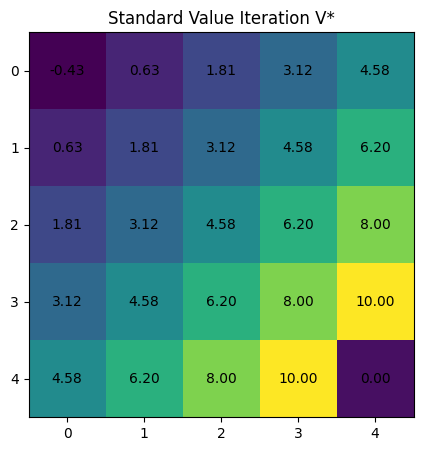

In [3]:
# Problem 3: Standard Value Iteration

env_5x5 = GridWorldEnvironment.make_5x5()
standard_vi = ValueIterationAgent(env_5x5, gamma=0.9, theta=1e-6, max_iterations=1000, logger=logger)
V_standard = standard_vi.run()
policy_standard = standard_vi.get_policy()

print("Standard Value Iteration - Value Function")
display(values_to_dataframe(V_standard, 5, 5).round(2))

print("Standard Value Iteration - Optimal Policy")
display(policy_to_dataframe(policy_standard, 5, 5))

plot_value_grid(V_standard, 5, 5, title="Standard Value Iteration V*")

2026-06-11 14:34:06,416 - INFO - In-Place Value Iteration started.
2026-06-11 14:34:06,418 - INFO - gamma=0.9, theta=1e-06, max_iterations=1000
2026-06-11 14:34:06,422 - INFO - In-Place VI iteration=1 delta=10.00000000
2026-06-11 14:34:06,423 - INFO - In-Place VI iteration=2 delta=9.00000000
2026-06-11 14:34:06,425 - INFO - In-Place VI iteration=3 delta=8.10000000
2026-06-11 14:34:06,426 - INFO - In-Place VI iteration=4 delta=7.29000000
2026-06-11 14:34:06,428 - INFO - In-Place VI iteration=5 delta=6.56100000
2026-06-11 14:34:06,433 - INFO - In-Place VI iteration=6 delta=5.90490000
2026-06-11 14:34:06,434 - INFO - In-Place VI iteration=7 delta=5.31441000
2026-06-11 14:34:06,437 - INFO - In-Place VI iteration=8 delta=4.78296900
2026-06-11 14:34:06,439 - INFO - In-Place VI iteration=9 delta=0.00000000
2026-06-11 14:34:06,440 - INFO - In-Place Value Iteration finished in 0.024261 seconds and 9 iterations.


In-Place Value Iteration - Value Function


,col 0,col 1,col 2,col 3,col 4
row 0,-0.43,0.63,1.81,3.12,4.58
row 1,0.63,1.81,3.12,4.58,6.20
row 2,1.81,3.12,4.58,6.20,8.00
row 3,3.12,4.58,6.20,8.00,10.00
row 4,4.58,6.20,8.00,10.00,0.00


In-Place Value Iteration - Optimal Policy


,col 0,col 1,col 2,col 3,col 4
row 0,→,→,→,↓,↓
row 1,→,→,→,→,↓
row 2,→,↓,→,→,↓
row 3,→,→,→,→,↓
row 4,→,→,→,→,G


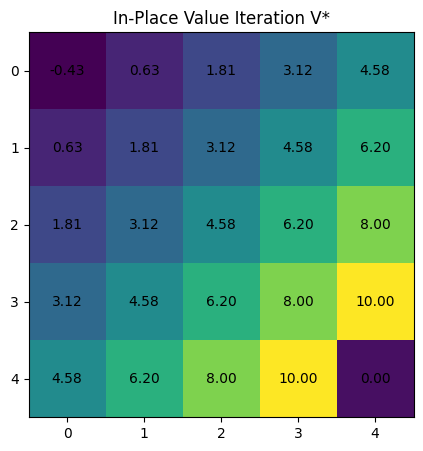

In [4]:
# Problem 3: In-Place Value Iteration

env_5x5_inplace = GridWorldEnvironment.make_5x5()
inplace_vi = InPlaceValueIterationAgent(env_5x5_inplace, gamma=0.9, theta=1e-6, max_iterations=1000, logger=logger)
V_inplace = inplace_vi.run()
policy_inplace = inplace_vi.get_policy()

print("In-Place Value Iteration - Value Function")
display(values_to_dataframe(V_inplace, 5, 5).round(2))

print("In-Place Value Iteration - Optimal Policy")
display(policy_to_dataframe(policy_inplace, 5, 5))

plot_value_grid(V_inplace, 5, 5, title="In-Place Value Iteration V*")

In [5]:
# Problem 3: Performance Comparison

comparison_p3 = pd.DataFrame({
    "Method": ["Standard Value Iteration", "In-Place Value Iteration"],
    "Iterations": [standard_vi.iterations, inplace_vi.iterations],
    "Runtime Seconds": [standard_vi.runtime_seconds, inplace_vi.runtime_seconds],
    "Complexity Comment": [
        "Uses a separate new value table each iteration. Complexity is about O(iterations * states * actions).",
        "Uses one value table and new values immediately. Complexity is similar but it may converge faster."
    ]
})

display(comparison_p3)

,Method,Iterations,Runtime Seconds,Complexity Comment
0,Standard Value Iteration,9,0.018608,Uses a separate new value table each iteration...
1,In-Place Value Iteration,9,0.024261,Uses one value table and new values immediatel...


## Problem 3 Explanation

Standard value iteration uses a copy of the old value table to update all states. This is easier to understand because all states in one iteration use the same old values.

In-place value iteration updates the same table directly. This means if a state was updated earlier in the same sweep, the next state can use this new value immediately. Because of this, in-place value iteration can sometimes need fewer iterations.

## Problem 3 Talking Points

**Talking Point A - Key Reinforcement Learning Feature**  
The main RL feature is finding optimal value function and optimal policy. Value iteration checks all possible actions and chooses the action with highest expected return. This is same idea as dynamic programming in Sutton and Barto.

**Talking Point B - Implementation and Testing Challenge**  
One challenge was comparing normal value iteration and in-place value iteration. Normal method uses old value table, but in-place method updates value directly. Because of this, the results should become same, but the number of iterations or time can be different.

**Talking Point C - Why This Is Reinforcement Learning**  
This is Reinforcement Learning because the gridworld has agent, state, action, reward, policy and value function. The agent tries to reach goal and avoid grey states. It learns best path based on reward system.

**Connection to Sutton and Barto pseudocode**  
The implementation maps to dynamic programming pseudocode by looping through states and applying the Bellman optimality backup. The policy is improved by selecting the action with the best value.

# Problem 4: Off-Policy Monte Carlo with Importance Sampling

In this problem, the same 5x5 environment is used.

- Behavior policy: random policy
- Target policy: greedy policy
- Discount factor: 0.9
- Episodes: 5000
- Maximum steps per episode: 100

The behavior policy explores the environment and creates episodes. The target policy is greedy and is improved from the learned Q-values. Importance sampling is needed because the episodes are generated by the behavior policy, but the values are estimated for the target policy.

2026-06-11 14:34:06,559 - INFO - Off-policy Monte Carlo started.
2026-06-11 14:34:06,560 - INFO - gamma=0.9, episodes=5000, max_steps=100
2026-06-11 14:34:06,781 - INFO - MC progress: episode 500/5000
2026-06-11 14:34:07,011 - INFO - MC progress: episode 1000/5000
2026-06-11 14:34:07,234 - INFO - MC progress: episode 1500/5000
2026-06-11 14:34:07,466 - INFO - MC progress: episode 2000/5000
2026-06-11 14:34:07,696 - INFO - MC progress: episode 2500/5000
2026-06-11 14:34:07,910 - INFO - MC progress: episode 3000/5000
2026-06-11 14:34:08,129 - INFO - MC progress: episode 3500/5000
2026-06-11 14:34:08,493 - INFO - MC progress: episode 4000/5000
2026-06-11 14:34:08,985 - INFO - MC progress: episode 4500/5000
2026-06-11 14:34:09,433 - INFO - MC progress: episode 5000/5000
2026-06-11 14:34:09,435 - INFO - Off-policy Monte Carlo finished in 2.875764 seconds.


Monte Carlo Estimated Value Function


,col 0,col 1,col 2,col 3,col 4
row 0,-0.44,0.62,1.75,3.05,4.45
row 1,0.61,1.78,3.05,4.53,6.11
row 2,1.72,3.07,4.45,6.12,7.93
row 3,3.05,4.50,6.13,7.95,10.00
row 4,4.52,6.11,7.95,10.00,0.00


Monte Carlo Greedy Target Policy


,col 0,col 1,col 2,col 3,col 4
row 0,↓,→,→,↓,↓
row 1,→,↓,→,↓,↓
row 2,→,↓,↓,↓,↓
row 3,→,→,↓,↓,↓
row 4,→,→,→,→,G


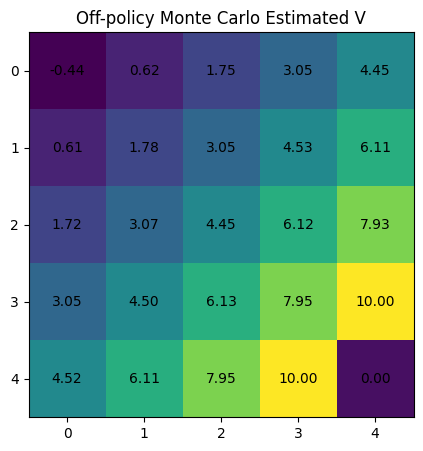

In [6]:
# Problem 4: Off-policy Monte Carlo with Importance Sampling

env_5x5_mc = GridWorldEnvironment.make_5x5()
mc_agent = MonteCarloOffPolicyAgent(env_5x5_mc, gamma=0.9, episodes=5000, max_steps=100, seed=42, logger=logger)
V_mc = mc_agent.run()
policy_mc = mc_agent.get_policy()

print("Monte Carlo Estimated Value Function")
display(values_to_dataframe(V_mc, 5, 5).round(2))

print("Monte Carlo Greedy Target Policy")
display(policy_to_dataframe(policy_mc, 5, 5))

plot_value_grid(V_mc, 5, 5, title="Off-policy Monte Carlo Estimated V")

In [7]:
# Problem 4: Compare Monte Carlo with Value Iteration

comparison_p4 = pd.DataFrame({
    "Item": ["Uses model", "Main input", "Speed", "Output type", "Challenge", "Runtime Seconds"],
    "Value Iteration": [
        "Yes, it uses transition and reward model",
        "All states and actions",
        "Usually faster for small gridworld",
        "More exact after convergence",
        "Need correct Bellman update and convergence check",
        round(standard_vi.runtime_seconds, 6)
    ],
    "Off-policy Monte Carlo": [
        "No full model needed, it learns from sampled episodes",
        "Generated episodes from behavior policy",
        "Needs many episodes, so it can be slower",
        "Approximate estimate because of sampling",
        "Random episodes, importance sampling, and high variance",
        round(mc_agent.runtime_seconds, 6)
    ]
})

display(comparison_p4)

,Item,Value Iteration,Off-policy Monte Carlo
0,Uses model,"Yes, it uses transition and reward model","No full model needed, it learns from sampled e..."
1,Main input,All states and actions,Generated episodes from behavior policy
2,Speed,Usually faster for small gridworld,"Needs many episodes, so it can be slower"
3,Output type,More exact after convergence,Approximate estimate because of sampling
4,Challenge,Need correct Bellman update and convergence check,"Random episodes, importance sampling, and high..."
5,Runtime Seconds,0.018608,2.875764


## Problem 4 Talking Points

**Talking Point A - Key Reinforcement Learning Feature**  
The key feature is off-policy Monte Carlo with importance sampling. The behavior policy is random and it creates episodes, but the target policy is greedy. Importance sampling helps to use random policy data to estimate greedy policy value.

**Talking Point B - Implementation and Testing Challenge**  
One challenge was avoiding infinite episodes. Since random policy can move around many times and not reach goal, I used max steps for each episode. Also Monte Carlo values can change a lot, so I used many episodes and random seed.

**Talking Point C - Why This Is Reinforcement Learning**  
This is RL because the value is learned from episodes and returns. The agent does not know the best answer directly. It explores the environment, gets rewards, calculates return, and improves policy from experience.

**Connection to Sutton and Barto pseudocode**  
The code follows the off-policy Monte Carlo control idea from Sutton and Barto. It works backwards through an episode, calculates return, updates Q-values using weighted importance sampling, and improves the greedy target policy.

# Final Notes

The notebook generated the log file in:

```text
logs/sample_execution.log
```

This log includes algorithm start/end messages, parameter values, iteration progress, episode progress, final runtime, and results information.


In [8]:
logger.info("Notebook execution finished.")

# Show first few lines of log file
with open("logs/sample_execution.log", "r", encoding="utf-8") as f:
    log_preview = "".join(f.readlines()[:20])

print(log_preview)

2026-06-11 14:34:09,690 - INFO - Notebook execution finished.


2026-06-11 14:34:06,035 - INFO - Notebook execution started.
2026-06-11 14:34:06,100 - INFO - Standard Value Iteration started.
2026-06-11 14:34:06,102 - INFO - gamma=0.9, theta=1e-06, max_iterations=1000
2026-06-11 14:34:06,103 - INFO - Standard VI iteration=1 delta=10.00000000
2026-06-11 14:34:06,105 - INFO - Standard VI iteration=2 delta=9.00000000
2026-06-11 14:34:06,107 - INFO - Standard VI iteration=3 delta=8.10000000
2026-06-11 14:34:06,109 - INFO - Standard VI iteration=4 delta=7.29000000
2026-06-11 14:34:06,111 - INFO - Standard VI iteration=5 delta=6.56100000
2026-06-11 14:34:06,112 - INFO - Standard VI iteration=6 delta=5.90490000
2026-06-11 14:34:06,114 - INFO - Standard VI iteration=7 delta=5.31441000
2026-06-11 14:34:06,115 - INFO - Standard VI iteration=8 delta=4.78296900
2026-06-11 14:34:06,117 - INFO - Standard VI iteration=9 delta=0.00000000
2026-06-11 14:34:06,118 - INFO - Standard Value Iteration finished in 0.018608 seconds and 9 iterations.
2026-06-11 14:34:06,416